In [1]:
from pathlib import Path
from etils import epath
import jax

maindir = Path('/home/dpoteryayev/SpectraFormer/notebook.ipynb').parent.resolve()

datadir = maindir / "data"

mixdir = datadir / "mixtures"
mixdir.mkdir(parents=True, exist_ok=True)

unmixdir = datadir / "unmixed"
unmixdir.mkdir(parents=True, exist_ok=True)

In [2]:
import xarray as xr
import matplotlib.pyplot as plt

In [3]:
unmixed_ds = xr.load_dataset("data/unmixed/min23_CorrGamma/unmixed_by_min23_CorrGamma_10_1_1_buffer1_18x18.nc")
unmixed_ds['wave_number'] = unmixed_ds['wave_number']
unmixed_ds

<xarray.Dataset>
Dimensions:                        (sample: 264, wave_number: 1015)
Coordinates:
  * sample                         (sample) int64 0 1 2 3 4 ... 260 261 262 263
  * wave_number                    (wave_number) float32 1.278e+03 ... 2.82e+03
Data variables:
    spectra                        (sample, wave_number) float32 0.2179 ... 0...
    masked_spectra                 (sample, wave_number) float32 -1.0 ... -1.0
    mask                           (sample, wave_number) bool False ... False
    predicted_spectra              (sample, wave_number) float32 0.1853 ... 0...
    predicted_difference           (sample, wave_number) float32 0.03258 ... ...
    filtered_spectra               (sample, wave_number) float32 0.2154 ... 0...
    filtered_predicted_difference  (sample, wave_number) float32 0.0298 ... -...

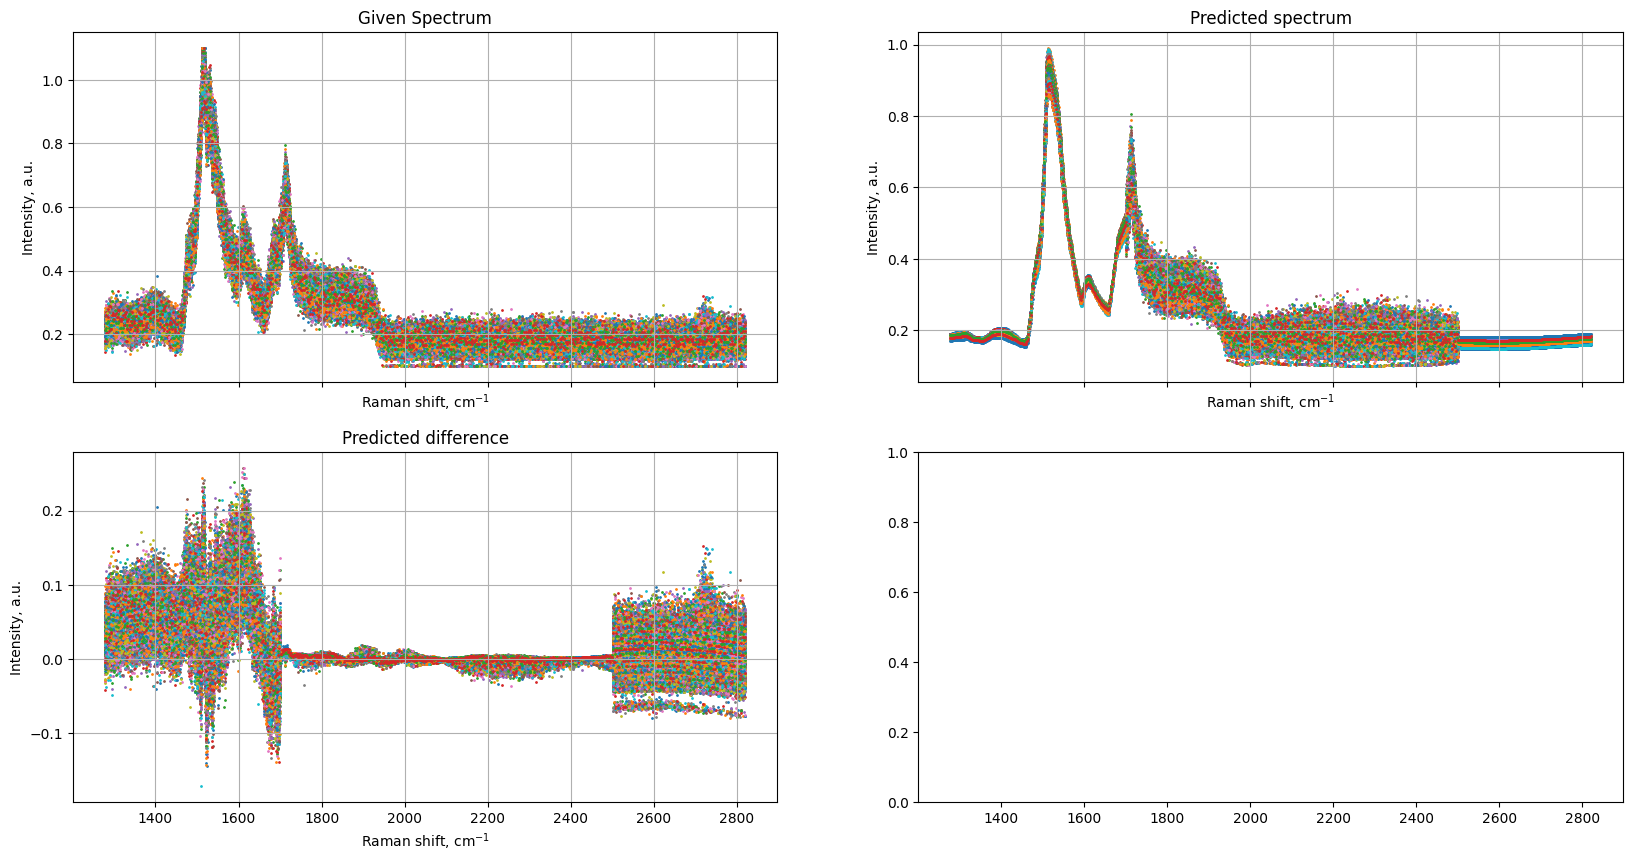

In [4]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

for i in range(len(unmixed_ds['sample'])):

    axes[0,0].scatter(x=unmixed_ds['wave_number'], y=unmixed_ds['spectra'][i], s=1)
    axes[0,0].set_xlabel('Raman shift, cm$^{-1}$')
    axes[0,0].set_ylabel('Intensity, a.u.')
    axes[0,0].set_title('Given Spectrum')
    axes[0,0].grid(visible=True, which='major', axis='both')

    axes[0,1].scatter(x=unmixed_ds['wave_number'], y=unmixed_ds['predicted_spectra'][i], s=1)
    axes[0,1].set_xlabel('Raman shift, cm$^{-1}$')
    axes[0,1].set_ylabel('Intensity, a.u.')
    axes[0,1].set_title('Predicted spectrum')
    axes[0,1].grid(visible=True, which='major', axis='both')

    axes[1,0].scatter(x=unmixed_ds['wave_number'], y=unmixed_ds['predicted_difference'][i], s=1)
    axes[1,0].set_xlabel('Raman shift, cm$^{-1}$')
    axes[1,0].set_ylabel('Intensity, a.u.')
    axes[1,0].set_title('Predicted difference')
    axes[1,0].grid(visible=True, which='major', axis='both')

plt.show()

In [5]:
def my_statistics(
    dataset,
    dim: str = 'sample'
    ):
    exp_val = dataset.mean(dim=[dim])
    variance = dataset.var(dim=[dim])
    std = dataset.std(dim=[dim])
    z1 = (dataset - exp_val)/std
    skewness = (z1**3).mean(dim=[dim])
    kurtosis = (z1**4).mean(dim=[dim])
    
    return exp_val, variance, std, skewness, kurtosis

In [6]:
ds1 = unmixed_ds.drop_vars(['mask','masked_spectra','predicted_spectra', 'spectra', 'filtered_spectra', 'filtered_predicted_difference']).to_dataarray(dim='predicted_difference').drop_vars(names='predicted_difference')
ds1

<xarray.DataArray (predicted_difference: 1, sample: 264, wave_number: 1015)>
array([[[ 3.2580197e-02,  3.2156214e-02,  1.9197777e-02, ...,
          1.1756569e-02,  3.8785040e-03,  3.5078093e-02],
        [ 2.9988587e-04,  4.8065588e-02,  6.4131618e-03, ...,
          1.8462703e-02, -3.3230051e-02, -2.4696410e-02],
        [ 4.8405603e-02,  3.5343856e-02,  4.1410655e-02, ...,
         -3.9406061e-02,  1.5895665e-02, -5.4091215e-05],
        ...,
        [ 3.1508133e-02,  3.7250891e-02,  6.1678872e-02, ...,
          1.5138224e-02,  7.3038042e-03, -3.1660095e-02],
        [ 2.8589785e-02,  4.0969253e-04,  3.4869447e-02, ...,
         -9.5255524e-03, -9.4281137e-04,  7.6609254e-03],
        [-4.9416721e-04,  8.3116993e-02,  2.4721920e-02, ...,
          4.5402452e-02,  2.9163286e-02, -1.9376427e-02]]], dtype=float32)
Coordinates:
  * sample       (sample) int64 0 1 2 3 4 5 6 7 ... 257 258 259 260 261 262 263
  * wave_number  (wave_number) float32 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
Dimensions without coordinates: predicted_difference

In [7]:
mean1 , var1, std1, skew1, kurt1 = my_statistics(ds1)
mean1

<xarray.DataArray (predicted_difference: 1, wave_number: 1015)>
array([[0.02911557, 0.04110176, 0.03958044, ..., 0.0071483 , 0.00956176,
        0.01071854]], dtype=float32)
Coordinates:
  * wave_number  (wave_number) float32 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
Dimensions without coordinates: predicted_difference

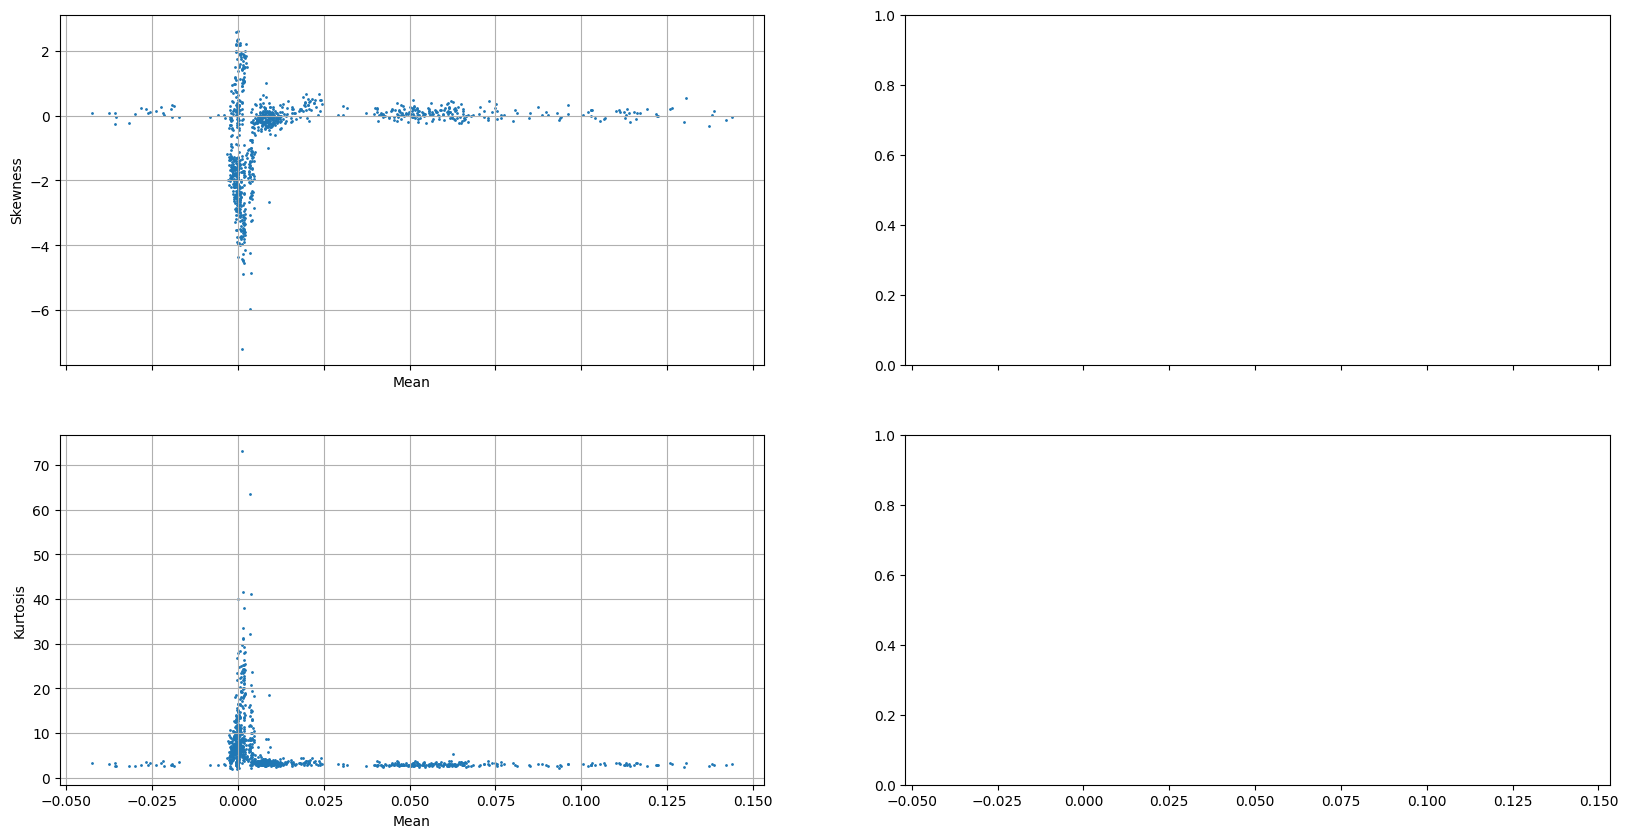

In [8]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean1, y=skew1, alpha=1, s=1)
axes[0,0].set_xlabel('Mean')
axes[0,0].set_ylabel('Skewness')
axes[0,0].set_title('')
axes[0,0].grid(visible=True, which='both', axis='both')

# axes[0,1].scatter(x=mean2, y=skew2, alpha=1, s=1)
# axes[0,1].set_xlabel('Mean')
# axes[0,1].set_ylabel('Skewness')
# axes[0,1].set_title('')
# axes[0,1].grid(visible=True, which='both', axis='both')
# axes[0,1].sharey(axes[0,0])

axes[1,0].scatter(x=mean1, y=kurt1, alpha=1, s=1)
axes[1,0].set_xlabel('Mean')
axes[1,0].set_ylabel('Kurtosis')
axes[1,0].set_title('')
axes[1,0].grid(visible=True, which='both', axis='both')

# axes[1,1].scatter(x=mean2, y=kurt2, alpha=1, s=1)
# axes[1,1].set_xlabel('Mean')
# axes[1,1].set_ylabel('Kurtosis')
# axes[1,1].set_title('')
# axes[1,1].grid(visible=True, which='both', axis='both')
# axes[1,1].sharey(axes[1,0])

plt.show()

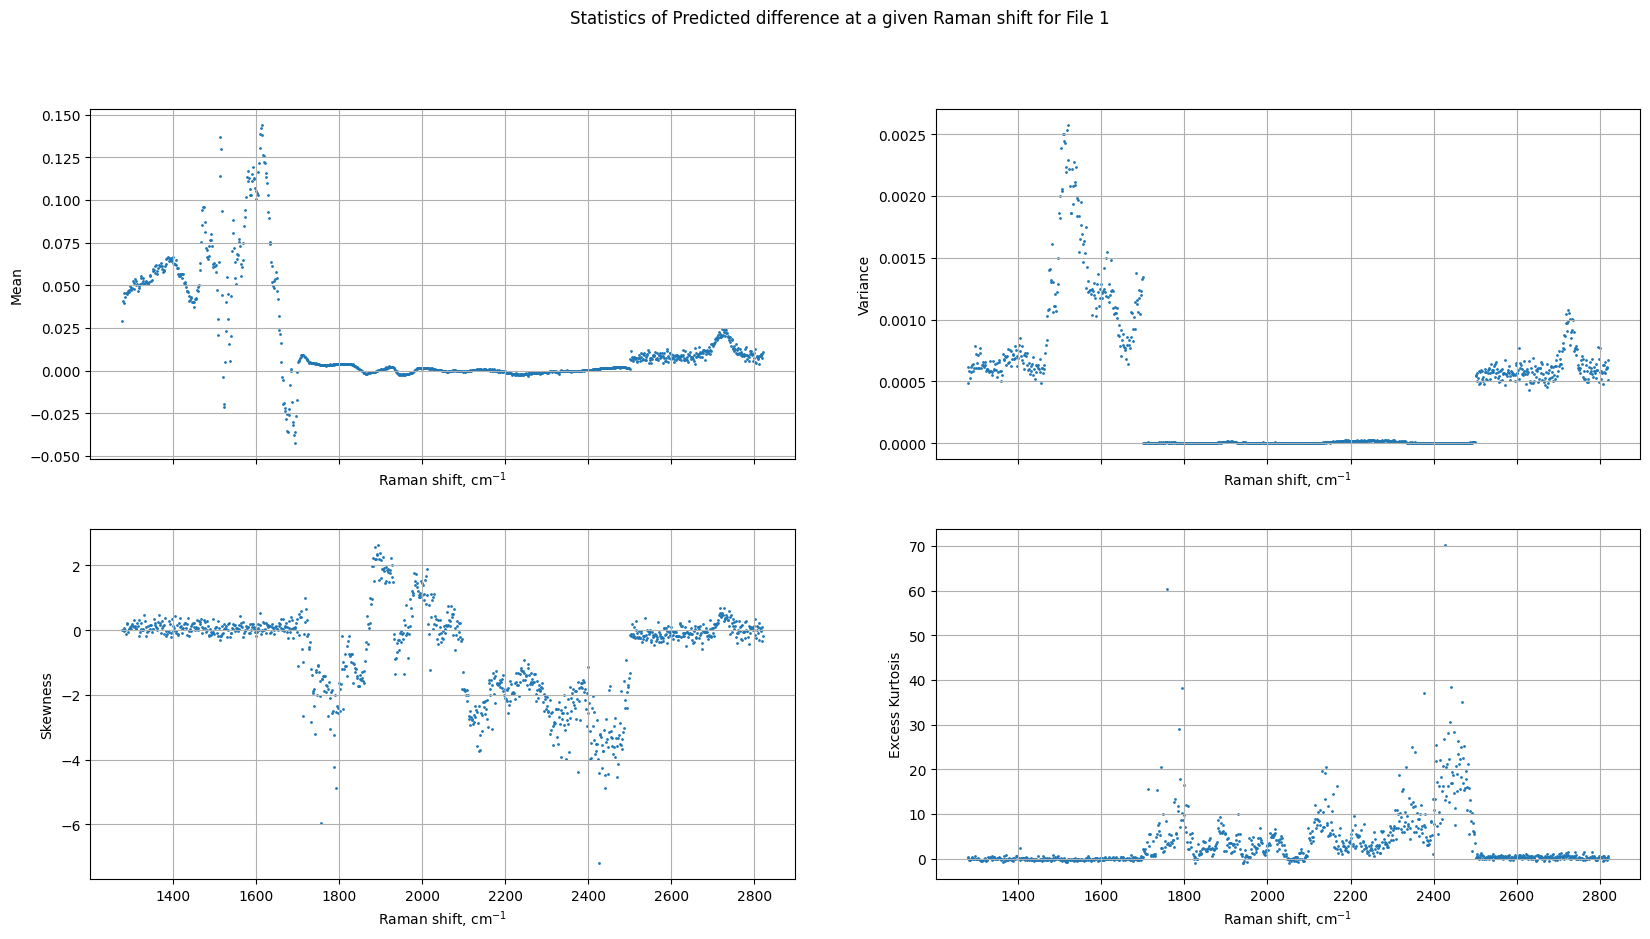

In [9]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

plt.suptitle('Statistics of Predicted difference at a given Raman shift for File 1')

axes[0,0].scatter(x=ds1['wave_number'], y=mean1, alpha=1, s=1)
axes[0,0].set_xlabel('Raman shift, cm$^{-1}$')
axes[0,0].set_ylabel('Mean')
axes[0,0].set_title('')
axes[0,0].grid(visible=True, which='both', axis='both')

axes[0,1].scatter(x=ds1['wave_number'], y=var1, alpha=1, s=1)
axes[0,1].set_xlabel('Raman shift, cm$^{-1}$')
axes[0,1].set_ylabel('Variance')
axes[0,1].set_title('')
axes[0,1].grid(visible=True, which='both', axis='both')
# axes[0,1].sharey(axes[0,0])

axes[1,0].scatter(x=ds1['wave_number'], y=skew1, alpha=1, s=1)
axes[1,0].set_xlabel('Raman shift, cm$^{-1}$')
axes[1,0].set_ylabel('Skewness')
axes[1,0].set_title('')
axes[1,0].grid(visible=True, which='both', axis='both')

axes[1,1].scatter(x=ds1['wave_number'], y=kurt1 - 3, alpha=1, s=1)
axes[1,1].set_xlabel('Raman shift, cm$^{-1}$')
axes[1,1].set_ylabel('Excess Kurtosis')
axes[1,1].set_title('')
axes[1,1].grid(visible=True, which='both', axis='both')
# axes[1,1].sharey(axes[1,0])

plt.show()

In [10]:
from spectraformer.input_pipeline import batch_sampler, preprocess_dataset

In [11]:
wavenum_ds = preprocess_dataset(
    xr.load_dataarray("data/SiC_19x10x3.nc")
)
wavenum_ds

Dropped 0 spectra


<xarray.DataArray (wave_number: 1015, spectra: 570)>
array([[0.16321972, 0.16322556, 0.17688599, ..., 0.16697275, 0.17813979,
        0.18525848],
       [0.17789186, 0.16324255, 0.18054267, ..., 0.15904082, 0.17665442,
        0.17776609],
       [0.17257985, 0.16325956, 0.17146665, ..., 0.16568322, 0.17817971,
        0.17402785],
       ...,
       [0.12190699, 0.11672867, 0.11595614, ..., 0.12191288, 0.11717111,
        0.11904489],
       [0.11359051, 0.12230961, 0.1182329 , ..., 0.12026475, 0.12093749,
        0.11670395],
       [0.11026167, 0.1111595 , 0.12050487, ..., 0.11364431, 0.11529626,
        0.13782147]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 19 19 19 19 19 19 19 19
  * X_1          (spectra) int64 0 0 0 1 1 1 2 2 2 3 3 ... 6 6 7 7 7 8 8 8 9 9 9
  * X_2          (spectra) int64 0 2 4 0 2 4 0 2 4 0 2 ... 2 4 0 2 4 0 2 4 0 2 4

In [12]:
print(wavenum_ds['wave_number'][0].item())
print(wavenum_ds['wave_number'][-1].item())

1278.296875
2820.420898


In [13]:
wavenum_ds['wave_number'][-1].item()-wavenum_ds['wave_number'][0].item()

1542.1240229999999

In [14]:
(wavenum_ds['wave_number'][-1].item()+wavenum_ds['wave_number'][0].item())/2

2049.3588865

In [15]:
(wavenum_ds['wave_number'][-1].item()-wavenum_ds['wave_number'][0].item())/2

771.0620114999999

In [16]:
from jax import random

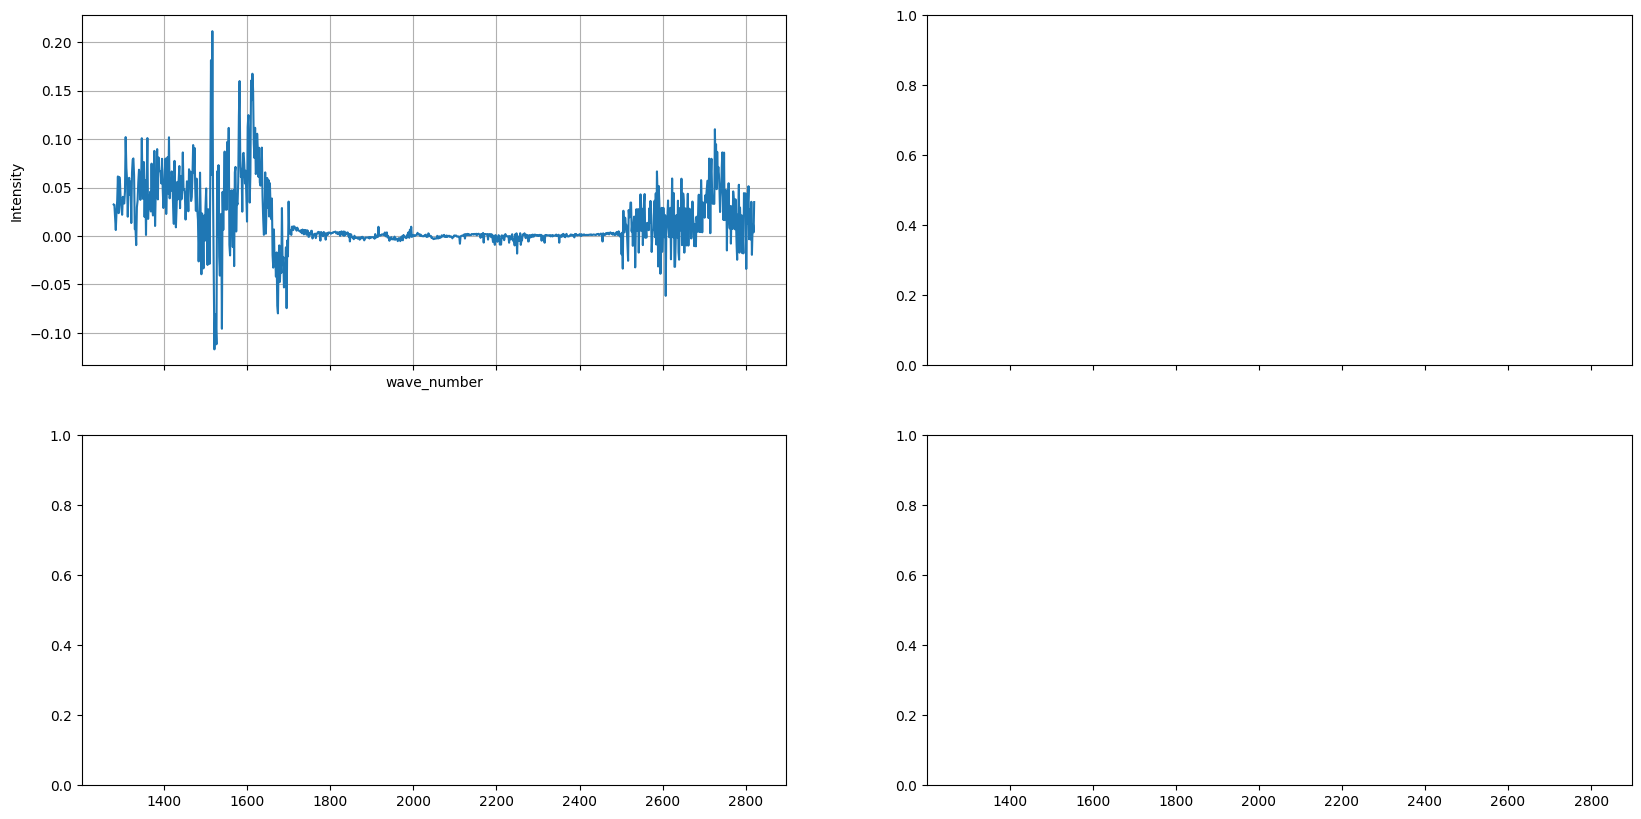

In [17]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

# axes[0,0].scatter(x=ds1[0]['wave_number'], y=ds1[0][0], alpha=1, s=1)
axes[0,0].plot(ds1[0]['wave_number'], ds1[0][0])
axes[0,0].set_xlabel('wave_number')
axes[0,0].set_ylabel('Intensity')
axes[0,0].set_title('')
axes[0,0].grid(visible=True, which='both', axis='both')

# axes[0,1].scatter(x=mean2, y=skew2, alpha=1, s=1)
# axes[0,1].set_xlabel('Mean')
# axes[0,1].set_ylabel('Skewness')
# axes[0,1].set_title('')
# axes[0,1].grid(visible=True, which='both', axis='both')
# axes[0,1].sharey(axes[0,0])

# axes[1,0].scatter(x=mean1, y=kurt1, alpha=1, s=1)
# axes[1,0].set_xlabel('Mean')
# axes[1,0].set_ylabel('Kurtosis')
# axes[1,0].set_title('')
# axes[1,0].grid(visible=True, which='both', axis='both')

# axes[1,1].scatter(x=mean2, y=kurt2, alpha=1, s=1)
# axes[1,1].set_xlabel('Mean')
# axes[1,1].set_ylabel('Kurtosis')
# axes[1,1].set_title('')
# axes[1,1].grid(visible=True, which='both', axis='both')
# axes[1,1].sharey(axes[1,0])

plt.show()

In [18]:
from scipy.signal import savgol_filter

In [19]:
spectrum1 = ds1[0][0]
spectrum1

<xarray.DataArray (wave_number: 1015)>
array([0.0325802 , 0.03215621, 0.01919778, ..., 0.01175657, 0.0038785 ,
       0.03507809], dtype=float32)
Coordinates:
    sample       int64 0
  * wave_number  (wave_number) float32 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03

In [20]:
filtered_spectrum1 = savgol_filter(spectrum1, 100, 5)
filtered_spectrum1

array([0.01527551, 0.02062563, 0.02534804, ..., 0.01291846, 0.01076875,
       0.00812303], dtype=float32)

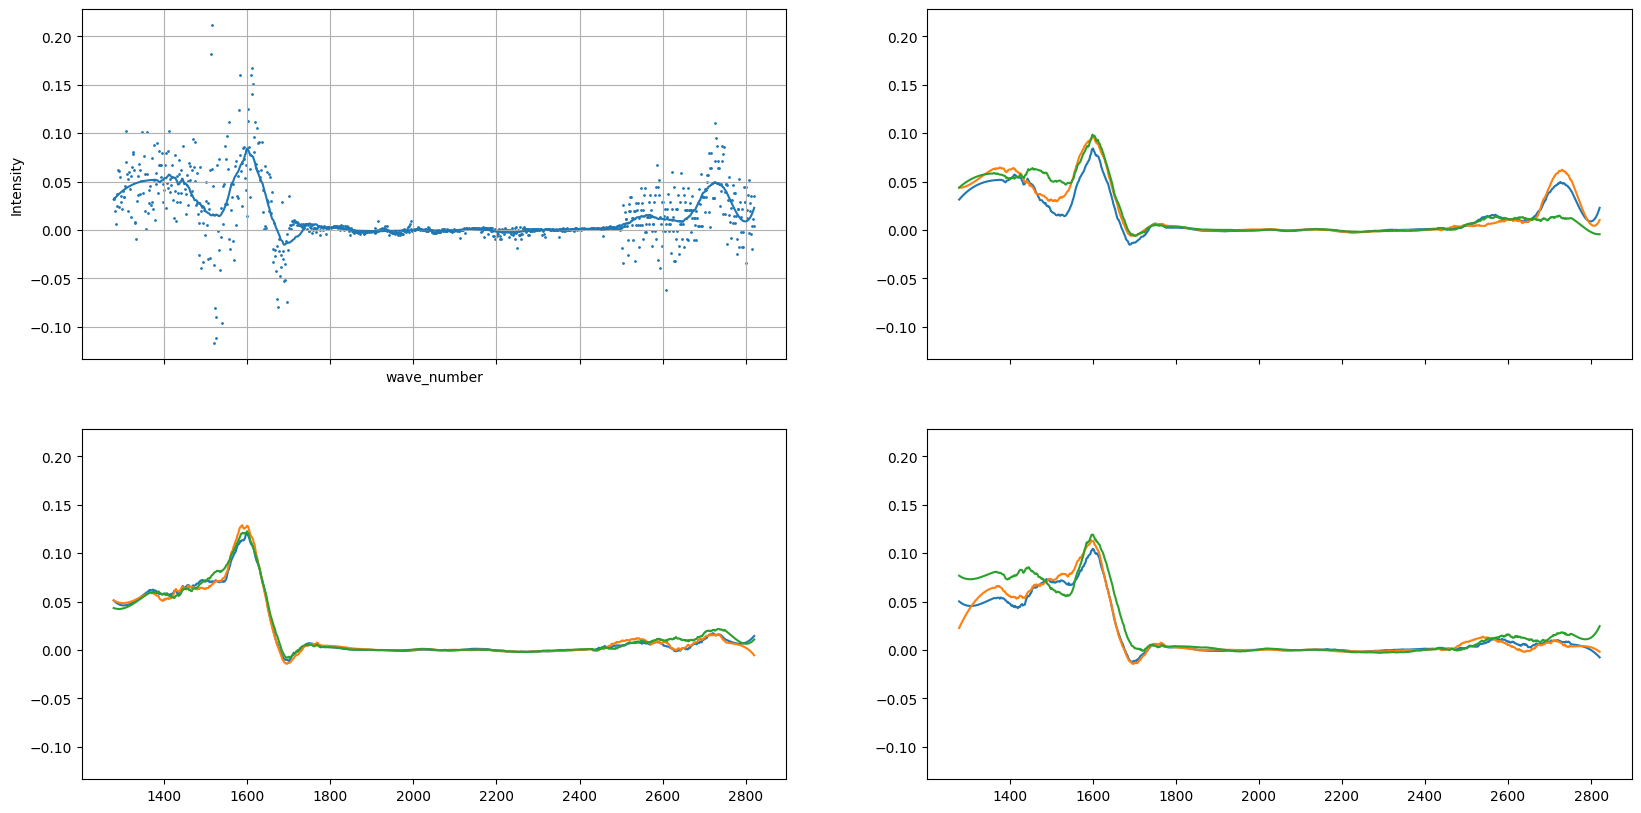

In [21]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

window_lenght = 100
polyorder=3

axes[0,0].scatter(ds1['wave_number'], ds1[0][0], alpha=1, s=1)
# axes[0,0].plot(spectrum1['wave_number'], spectrum1)
axes[0,0].plot(ds1['wave_number'], savgol_filter(ds1[0][0], window_lenght, polyorder))
axes[0,0].set_xlabel('wave_number')
axes[0,0].set_ylabel('Intensity')
axes[0,0].set_title('')
axes[0,0].grid(visible=True, which='both', axis='both')

for i in range(3):
    axes[0,1].plot(ds1['wave_number'], savgol_filter(ds1[0][i], window_lenght, polyorder))
    axes[1,0].plot(ds1['wave_number'], savgol_filter(ds1[0][i+50], window_lenght, polyorder))
    axes[1,1].plot(ds1['wave_number'], savgol_filter(ds1[0][i+70], window_lenght, polyorder))

axes[0,1].sharey(axes[0,0])
axes[1,0].sharey(axes[0,0])
axes[1,1].sharey(axes[0,0])

plt.show()

In [22]:
unmixed_ds2 = xr.load_dataset("data/unmixed/min23_CorrGamma/unmixed_by_min23_CorrGamma_5_5_1_buffer2_11x11.nc")
unmixed_ds2['wave_number'] = unmixed_ds2['wave_number']
unmixed_ds2

<xarray.Dataset>
Dimensions:                        (sample: 120, wave_number: 1015)
Coordinates:
  * sample                         (sample) int64 0 1 2 3 4 ... 116 117 118 119
  * wave_number                    (wave_number) float32 1.278e+03 ... 2.82e+03
Data variables:
    spectra                        (sample, wave_number) float32 0.1916 ... 0...
    masked_spectra                 (sample, wave_number) float32 -1.0 ... -1.0
    mask                           (sample, wave_number) bool False ... False
    predicted_spectra              (sample, wave_number) float32 0.171 ... 0.137
    predicted_difference           (sample, wave_number) float32 0.02058 ... ...
    filtered_spectra               (sample, wave_number) float32 0.1905 ... 0...
    filtered_predicted_difference  (sample, wave_number) float32 0.02002 ... ...

In [23]:
ds2 = unmixed_ds2.drop_vars(['mask','masked_spectra','predicted_spectra', 'spectra', 'filtered_spectra', 'filtered_predicted_difference']).to_dataarray(dim='predicted_difference').drop_vars(names='predicted_difference')
ds2

<xarray.DataArray (predicted_difference: 1, sample: 120, wave_number: 1015)>
array([[[ 0.02058019,  0.0148973 ,  0.00506045, ..., -0.02441879,
         -0.00719056,  0.00015269],
        [ 0.0053758 ,  0.01128398,  0.01505035, ...,  0.0001384 ,
         -0.00462861, -0.02823423],
        [ 0.02064885,  0.02085403,  0.01886129, ..., -0.01693032,
         -0.00761096, -0.00768225],
        ...,
        [-0.00802615,  0.01801915,  0.01053989, ..., -0.00255042,
         -0.02340734, -0.00268361],
        [ 0.01053174,  0.01473814,  0.00939801, ..., -0.0158052 ,
         -0.01115459,  0.00054957],
        [ 0.00118706,  0.00528526,  0.00729044, ..., -0.00666276,
         -0.01366804, -0.00909872]]], dtype=float32)
Coordinates:
  * sample       (sample) int64 0 1 2 3 4 5 6 7 ... 113 114 115 116 117 118 119
  * wave_number  (wave_number) float32 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
Dimensions without coordinates: predicted_difference

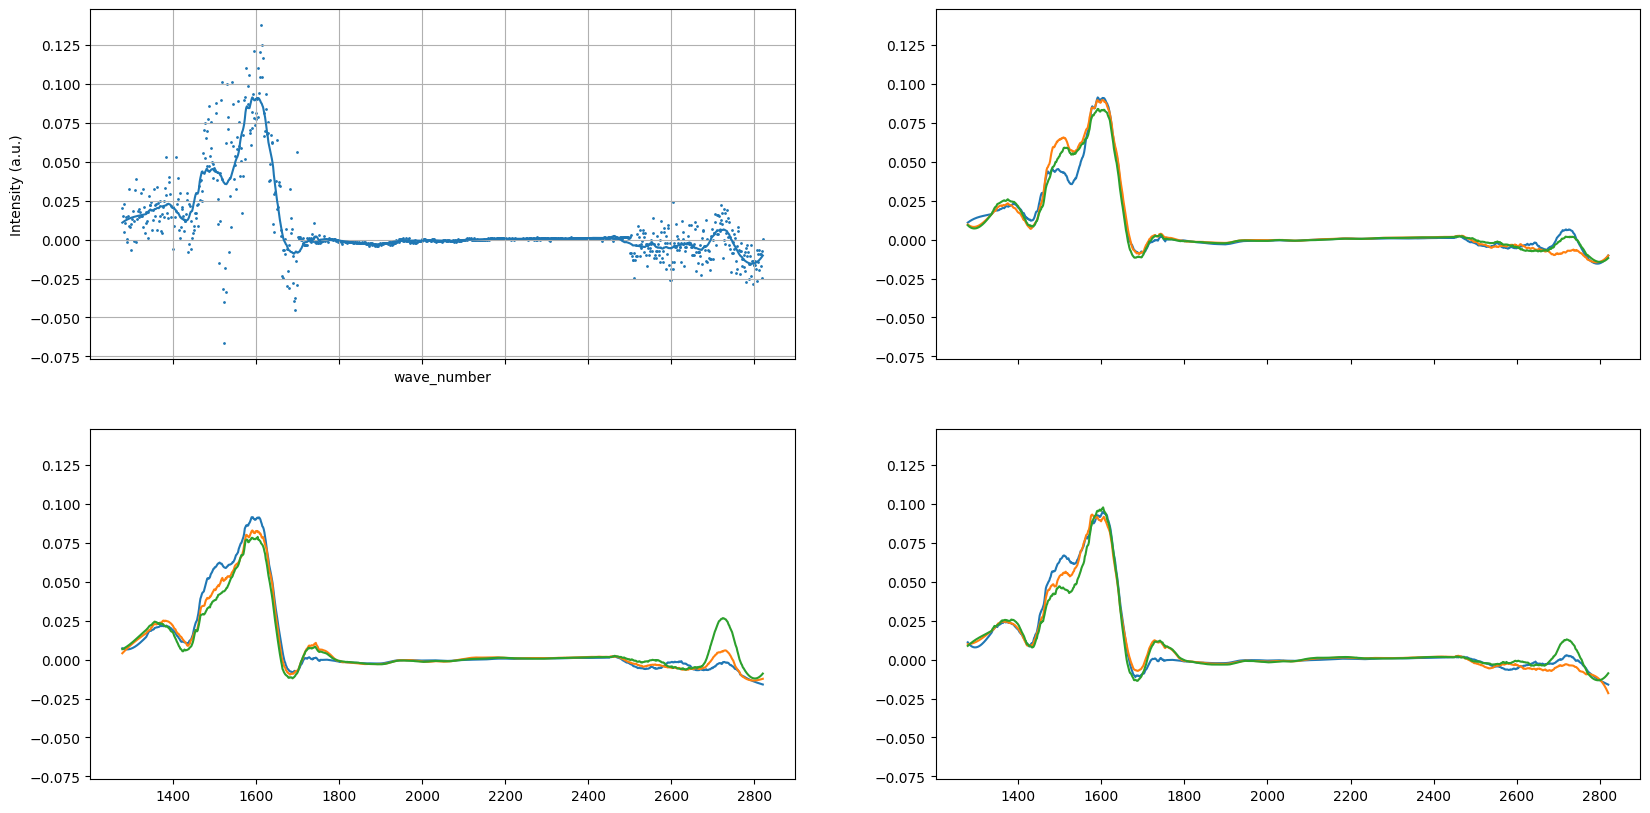

In [24]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

window_lenght = 70
polyorder=3

axes[0,0].scatter(ds2['wave_number'], ds2[0][0], alpha=1, s=1)
# axes[0,0].plot(spectrum1['wave_number'], spectrum1)
axes[0,0].plot(ds2['wave_number'], savgol_filter(ds2[0][0], window_lenght, polyorder))
axes[0,0].set_xlabel('wave_number')
axes[0,0].set_ylabel('Intensity (a.u.)')
axes[0,0].set_title('')
axes[0,0].grid(visible=True, which='both', axis='both')

axes[0,1].sharey(axes[0,0])
axes[1,0].sharey(axes[0,0])
axes[1,1].sharey(axes[0,0])

for i in range(3):
    axes[0,1].plot(ds2['wave_number'], savgol_filter(ds2[0][i], window_lenght, polyorder))
    axes[1,0].plot(ds2['wave_number'], savgol_filter(ds2[0][i+50], window_lenght, polyorder))
    axes[1,1].plot(ds2['wave_number'], savgol_filter(ds2[0][i+70], window_lenght, polyorder))


plt.show()

In [25]:
filtered_thing = savgol_filter(ds2[0][0], 100, 9)
filtered_thing

array([ 0.02002144,  0.01596619,  0.013105  , ..., -0.00990699,
       -0.00828263, -0.00645573], dtype=float32)

In [26]:
ds2

<xarray.DataArray (predicted_difference: 1, sample: 120, wave_number: 1015)>
array([[[ 0.02058019,  0.0148973 ,  0.00506045, ..., -0.02441879,
         -0.00719056,  0.00015269],
        [ 0.0053758 ,  0.01128398,  0.01505035, ...,  0.0001384 ,
         -0.00462861, -0.02823423],
        [ 0.02064885,  0.02085403,  0.01886129, ..., -0.01693032,
         -0.00761096, -0.00768225],
        ...,
        [-0.00802615,  0.01801915,  0.01053989, ..., -0.00255042,
         -0.02340734, -0.00268361],
        [ 0.01053174,  0.01473814,  0.00939801, ..., -0.0158052 ,
         -0.01115459,  0.00054957],
        [ 0.00118706,  0.00528526,  0.00729044, ..., -0.00666276,
         -0.01366804, -0.00909872]]], dtype=float32)
Coordinates:
  * sample       (sample) int64 0 1 2 3 4 5 6 7 ... 113 114 115 116 117 118 119
  * wave_number  (wave_number) float32 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
Dimensions without coordinates: predicted_difference

In [27]:
# First dim - fake, there is only one object, Second - sample, third - intensity value
ds2[0][0:2]

<xarray.DataArray (sample: 2, wave_number: 1015)>
array([[ 0.02058019,  0.0148973 ,  0.00506045, ..., -0.02441879,
        -0.00719056,  0.00015269],
       [ 0.0053758 ,  0.01128398,  0.01505035, ...,  0.0001384 ,
        -0.00462861, -0.02823423]], dtype=float32)
Coordinates:
  * sample       (sample) int64 0 1
  * wave_number  (wave_number) float32 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03

In [28]:
unmixed_ds

<xarray.Dataset>
Dimensions:                        (sample: 264, wave_number: 1015)
Coordinates:
  * sample                         (sample) int64 0 1 2 3 4 ... 260 261 262 263
  * wave_number                    (wave_number) float32 1.278e+03 ... 2.82e+03
Data variables:
    spectra                        (sample, wave_number) float32 0.2179 ... 0...
    masked_spectra                 (sample, wave_number) float32 -1.0 ... -1.0
    mask                           (sample, wave_number) bool False ... False
    predicted_spectra              (sample, wave_number) float32 0.1853 ... 0...
    predicted_difference           (sample, wave_number) float32 0.03258 ... ...
    filtered_spectra               (sample, wave_number) float32 0.2154 ... 0...
    filtered_predicted_difference  (sample, wave_number) float32 0.0298 ... -...

In [29]:
unmixed_ds3 = xr.load_dataset("data/unmixed/min30_GeomLoss/unmixed_by_min30_GeomLoss_5_5_1_buffer2_11x11.nc")
ds3 = unmixed_ds2.drop_vars(['mask','masked_spectra','predicted_spectra', 'spectra', 'filtered_spectra', 'filtered_predicted_difference']).to_dataarray(dim='predicted_difference').drop_vars(names='predicted_difference')
unmixed_ds3

<xarray.Dataset>
Dimensions:                        (sample: 120, wave_number: 1015)
Coordinates:
  * sample                         (sample) int64 0 1 2 3 4 ... 116 117 118 119
  * wave_number                    (wave_number) float32 1.278e+03 ... 2.82e+03
Data variables:
    spectra                        (sample, wave_number) float32 0.1916 ... 0...
    masked_spectra                 (sample, wave_number) float32 -1.0 ... -1.0
    mask                           (sample, wave_number) bool False ... False
    predicted_spectra              (sample, wave_number) float32 0.1807 ... 0...
    predicted_difference           (sample, wave_number) float32 0.01092 ... ...
    filtered_spectra               (sample, wave_number) float32 0.1905 ... 0...
    filtered_predicted_difference  (sample, wave_number) float32 0.01154 ... ...

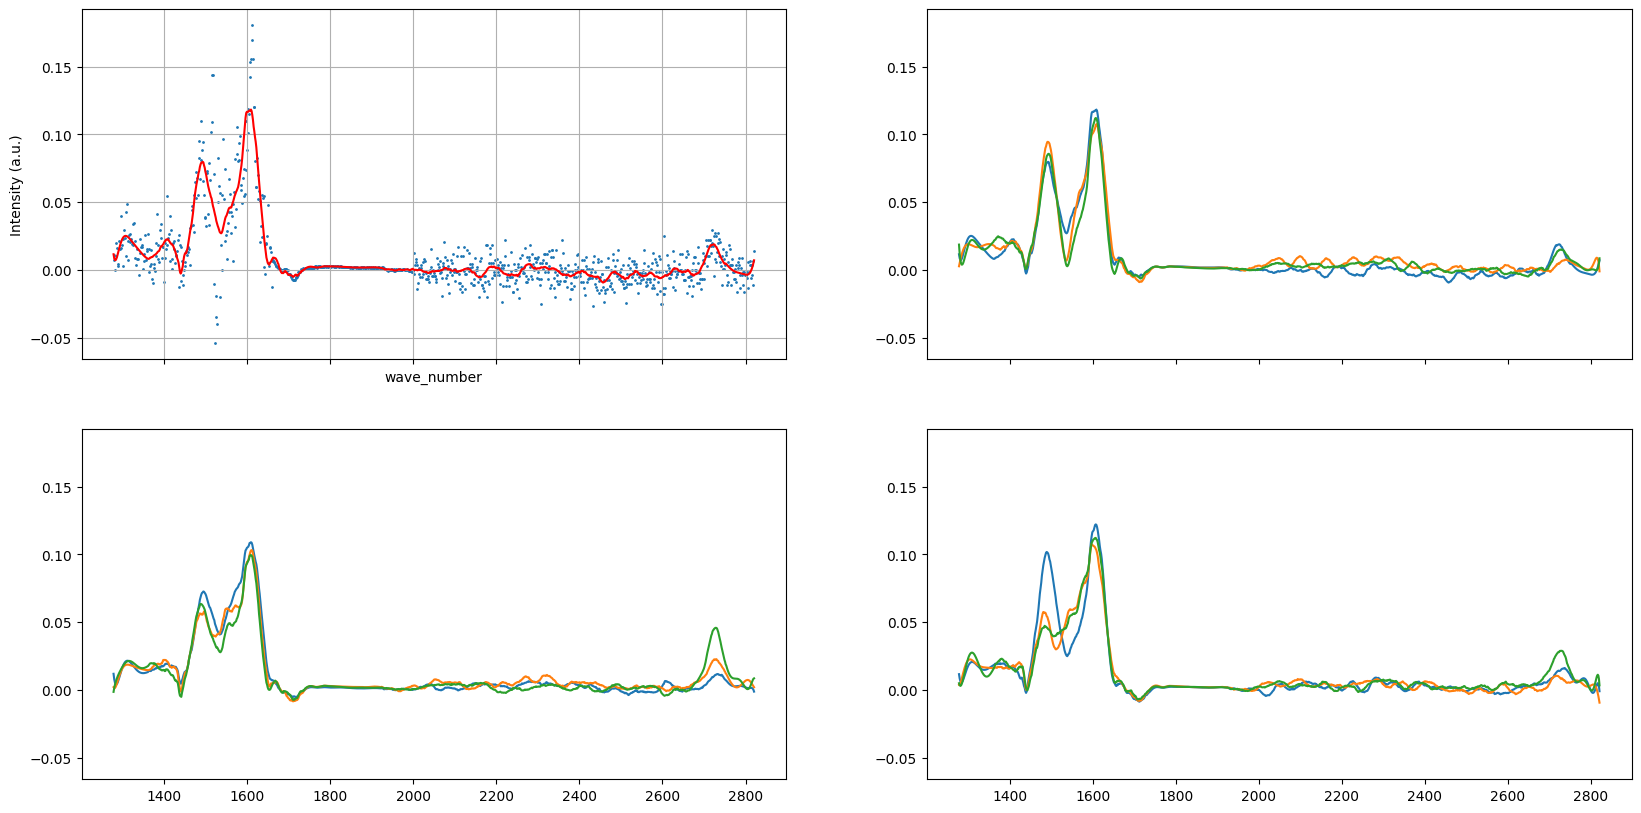

In [30]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(unmixed_ds3['wave_number'], unmixed_ds3['predicted_difference'][0], alpha=1, s=1)
axes[0,0].plot(unmixed_ds3['wave_number'], unmixed_ds3['filtered_predicted_difference'][0], 'red')
axes[0,0].set_xlabel('wave_number')
axes[0,0].set_ylabel('Intensity (a.u.)')
axes[0,0].set_title('')
axes[0,0].grid(visible=True, which='both', axis='both')

axes[0,1].sharey(axes[0,0])
axes[1,0].sharey(axes[0,0])
axes[1,1].sharey(axes[0,0])

for i in range(3):
    axes[0,1].plot(unmixed_ds3['wave_number'], unmixed_ds3['filtered_predicted_difference'][i])
    axes[1,0].plot(unmixed_ds3['wave_number'], unmixed_ds3['filtered_predicted_difference'][i+50])
    axes[1,1].plot(unmixed_ds3['wave_number'], unmixed_ds3['filtered_predicted_difference'][i+70])


plt.show()

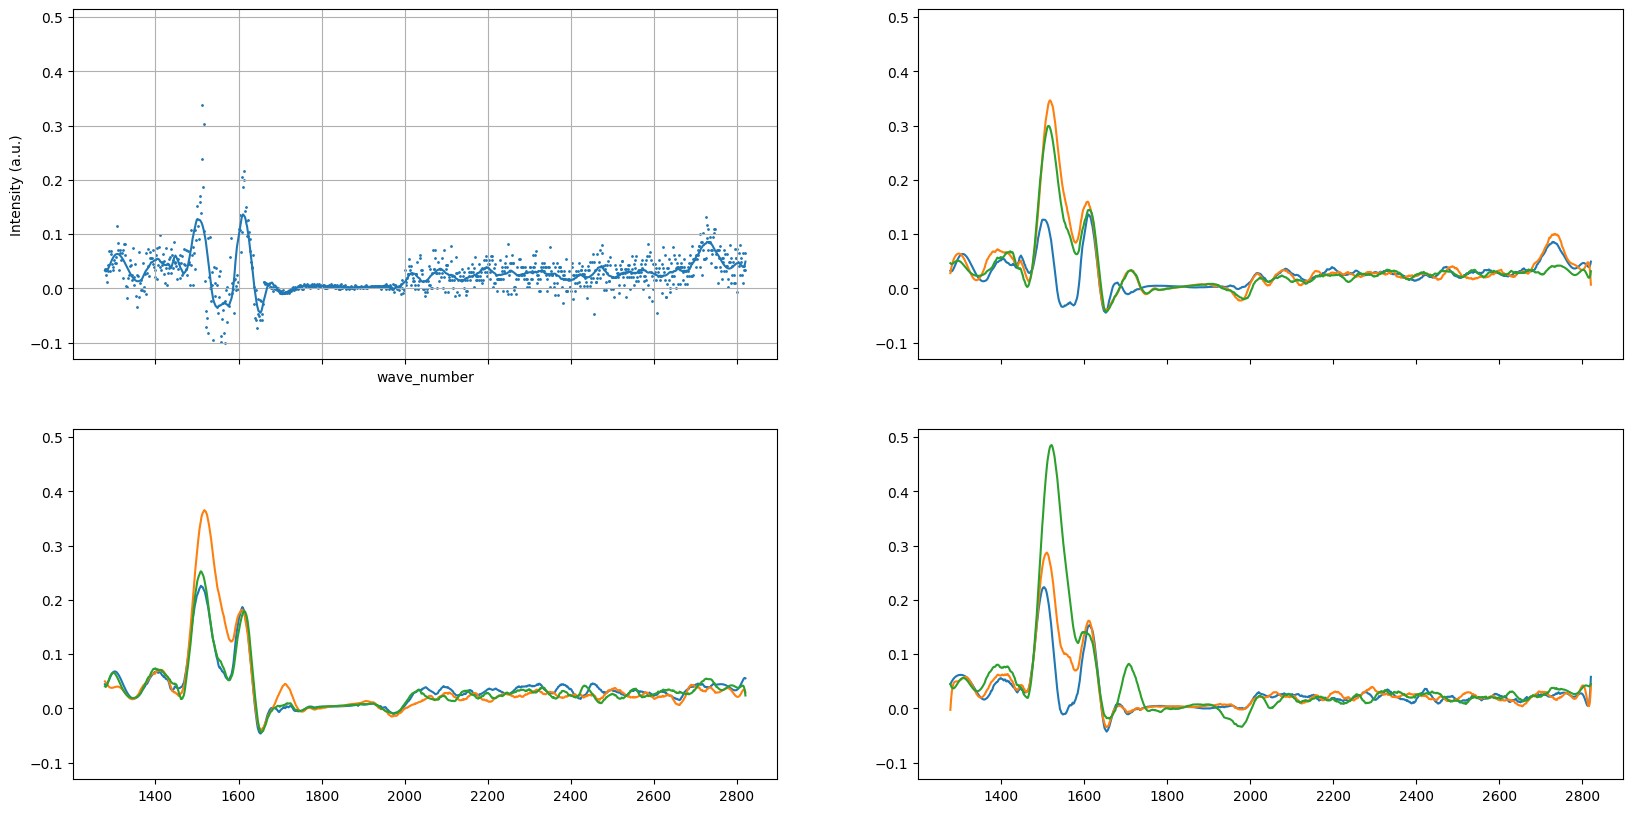

In [31]:
unmixed_ds4 = xr.load_dataset("data/unmixed/min30_GeomLoss/unmixed_by_min30_GeomLoss_10_1_1_buffer1_18x18.nc")
ds4 = unmixed_ds2.drop_vars(['mask','masked_spectra','predicted_spectra', 'spectra', 'filtered_spectra', 'filtered_predicted_difference']).to_dataarray(dim='predicted_difference').drop_vars(names='predicted_difference')

fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(unmixed_ds4['wave_number'], unmixed_ds4['predicted_difference'][0], alpha=1, s=1)
axes[0,0].plot(unmixed_ds4['wave_number'], unmixed_ds4['filtered_predicted_difference'][0])
axes[0,0].set_xlabel('wave_number')
axes[0,0].set_ylabel('Intensity (a.u.)')
axes[0,0].set_title('')
axes[0,0].grid(visible=True, which='both', axis='both')

axes[0,1].sharey(axes[0,0])
axes[1,0].sharey(axes[0,0])
axes[1,1].sharey(axes[0,0])

for i in range(3):
    axes[0,1].plot(unmixed_ds4['wave_number'], unmixed_ds4['filtered_predicted_difference'][i])
    axes[1,0].plot(unmixed_ds4['wave_number'], unmixed_ds4['filtered_predicted_difference'][i+50])
    axes[1,1].plot(unmixed_ds4['wave_number'], unmixed_ds4['filtered_predicted_difference'][i+70])


plt.show()